In [ ]:
# Library imports
import os
import numpy as np
import pandas as pd
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import json

SHARED_DRIVE_PATH = "/content/drive/MyDrive/CS790_L7 final project"
IMAGE_DIR = './drive/MyDrive/CS790_L7 final project/OA-severity-classification/data/raw/images/Finger Joints/'
DATA_DIR = './drive/MyDrive/CS790_L7 final project/OA-severity-classification/data/splits/'
REPORTS_DIR = './drive/MyDrive/CS790_L7 final project/OA-severity-classification/reports'
os.listdir(SHARED_DRIVE_PATH)

['slides',
 'minute meetings',
 'OA-severity-classification',
 'Project Proposal.gdoc',
 'CS790 Proposal Template.docx',
 'final CS790 Proposal .docx']

In [ ]:
import cv2
import numpy as np
from PIL import Image
from glob import glob
# CLAHE transform for improved contrast enhancement
def CLAHETransform(img):
  img = np.array(img)
  img = cv2.GaussianBlur(img, (5, 5), 0)
   # If image is RGB, convert to grayscale first
  if len(img.shape) == 3:
      img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
  tform = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
  img = tform.apply(img)
  img = Image.fromarray(img)
  return img


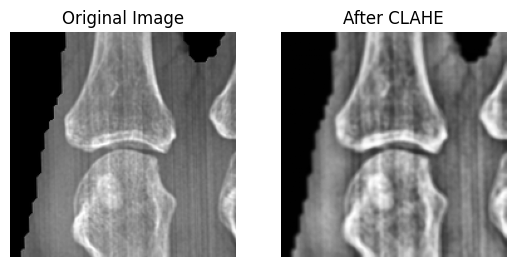

In [ ]:
# show sample with CLAHE
import matplotlib.pyplot as plt
image_dir = './drive/MyDrive/CS790_L7 final project/OA-severity-classification/data/raw/images/Finger Joints/'
imlist = glob(os.path.join(image_dir,'*.png'))
test = cv2.imread(imlist[5])
clahe_test = CLAHETransform(test)
fig, ax = plt.subplots(1,2)
ax[0].imshow(test, cmap='gray')
ax[0].set_axis_off()
ax[0].set_title('Original Image')
ax[1].imshow(clahe_test, cmap='gray')
ax[1].set_axis_off()
ax[1].set_title('After CLAHE')
plt.show()

In [ ]:
# Apply training transform (with augmentation)
def get_train_transform(weights):
    base_transform = weights.transforms()
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),  # small angles only
        transforms.Lambda(lambda img: CLAHETransform(img)),
        transforms.Grayscale(num_output_channels=3),
        base_transform, # resize and normalize to match pretrained weights
    ])

# validation transforms (as-is)
def get_val_transform(weights):
    base_transform = weights.transforms()
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Lambda(lambda img: CLAHETransform(img)),
        transforms.Grayscale(num_output_channels=3),
        base_transform, # resize and normalize to match pretrained weights
    ])

In [ ]:
# Reading and sampling data for model
def load_dataset_from_csv(csv_file, img_dir=None, transform=None):
    df = pd.read_csv(csv_file)
    # Try undersampling the majority classes (170 of each class)
    all_data = pd.DataFrame()
    for i in df['kl_grade'].unique():
        tmp = df[df['kl_grade']==i].copy(deep=True).reset_index(drop=True).head(170)
        all_data = pd.concat([all_data, tmp], ignore_index=True)
    df = all_data
    data = []
    for idx, row in df.iterrows():
      # location of data needed
        img_name = row['image_path'].split('\\')[-1]
        label = int(row['kl_grade'])
        img_path = os.path.join(img_dir, img_name).replace('\\','/') if img_dir else img_name

        if not os.path.exists(img_path):
            continue  # skip bad paths
        img = Image.open(img_path).convert("L")
        if transform:
            img = transform(img)
        # Add tuple of image, label
        data.append((img, label))
    return data

In [ ]:
# create data loaders with transforms
def create_dataloaders(train_csv, val_csv, img_dir):
    train_transform = get_train_transform(weights=ResNet18_Weights.DEFAULT)
    val_transform = get_val_transform(weights=ResNet18_Weights.DEFAULT)
    train_data = load_dataset_from_csv(train_csv, img_dir, train_transform)
    val_data = load_dataset_from_csv(val_csv, img_dir, val_transform)
    train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=32)
    return train_loader, val_loader

In [ ]:
# model creation - backbone + custom classifier
def create_model(num_classes=5):
    weights = ResNet18_Weights.DEFAULT # use pretrained weights
    model = models.resnet18(weights=weights)
    num_features = model.fc.in_features
    # Add a dropout layer to prevent overfitting
    model.dropout = nn.Dropout2d(p=0.5),
    model.fc = nn.Linear(num_features, num_classes)
    return model

In [ ]:
# metrics per epoch
def compute_metrics(outputs, labels, num_classes):
    _, preds = torch.max(outputs, 1)
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    accuracy = correct / total # accuracy, overall
    preds = preds.cpu()
    labels = labels.cpu()

    f1_per_class = []
    supports = []

    for c in range(num_classes):
       # per-grade metrics
        tp = ((preds == c) & (labels == c)).sum().item()
        fp = ((preds == c) & (labels != c)).sum().item()
        fn = ((preds != c) & (labels == c)).sum().item()
        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        f1_per_class.append(f1)
        supports.append((labels == c).sum().item())

    # Overall accuracy and F1
    macro_f1 = sum(f1_per_class) / num_classes
    total_support = sum(supports)
    return accuracy, macro_f1

In [ ]:
# Early stopping initializer
def init_early_stopping(mode="max", patience=10, min_delta=1e-4):
    return {
        "mode": mode,              # "max" for F1/AUC, "min" for loss
        "patience": patience,
        "min_delta": min_delta,
        "best": None,
        "counter": 0,
        "stop": False
    }

# early stopping updates
def update_early_stopping(es, current_value):
    if es["best"] is None:
        es["best"] = current_value
        return es
    improvement = (
        current_value > es["best"] + es["min_delta"]
        if es["mode"] == "max"
        else current_value < es["best"] - es["min_delta"]
    )

    if improvement:
        es["best"] = current_value
        es["counter"] = 0
    else:
        es["counter"] += 1

    if es["counter"] >= es["patience"]:
        es["stop"] = True

    return es

In [ ]:
# freeze and unfreeze model
def freeze_backbone(model):
    for name, param in model.named_parameters():
        if not name.startswith("fc"):
            param.requires_grad = False
def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True

In [ ]:
# model evaluation function
def evaluate(model, loader, device, criterion):
    model.eval()
    total_loss = 0
    total_acc = 0
    total_f1 = 0
    batches = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images) # predictions
            loss = criterion(outputs, labels) # loss function
            acc, f1 = compute_metrics(outputs, labels, num_classes=5) # get metrics
            total_loss += loss.item()
            total_acc += acc
            total_f1 += f1
            batches += 1

    return {
        "loss": total_loss / batches,
        "accuracy": total_acc / batches,
        "f1": total_f1 / batches
    }

# training function
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-4, freeze_epochs=5):
    best_score = -float("inf")
    best_model_state = None
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)
    # initialize history dictionary
    history = {
        "train_loss": [],
        "train_acc": [],
        "train_f1": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": []
    }

    es = init_early_stopping(mode="max", patience=5)
    # Use cross entropy loss
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    freeze_backbone(model)
    # Use Adam as optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)

    for epoch in range(epochs):
      if epoch == freeze_epochs:
        print("\nUnfreezing backbone...")
        unfreeze_all(model)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr/10, weight_decay=1e-3)
      model.train()
      # collect metrics over all epochs to find the best one
      total_loss = 0
      total_acc = 0
      total_f1 = 0
      batches = 0
      for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            acc, f1 = compute_metrics(outputs, labels, num_classes=5)
            total_loss += loss.item()
            total_acc += acc
            total_f1 += f1
            batches += 1
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
      print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")
      # evaluate training metrics
      train_metrics = {"loss": total_loss / batches,
        "accuracy": total_acc / batches,
        "f1": total_f1 / batches}
      # compute validation metrics
      val_metrics = evaluate(model, val_loader, device, criterion)
      current_score = val_metrics["f1"]

      # find best score
      if current_score > best_score:
        best_score = current_score
        best_model_state = model.state_dict()
        print(f'New best model (F1: {best_score:.4f})")
        # Save history
      history["train_loss"].append(train_metrics["loss"])
      history["train_acc"].append(train_metrics["accuracy"])
      history["train_f1"].append(train_metrics["f1"])

      history["val_loss"].append(val_metrics["loss"])
      history["val_acc"].append(val_metrics["accuracy"])
      history["val_f1"].append(val_metrics["f1"])

      print(f"\nEpoch {epoch+1}")
      print(f"Train - Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}, F1: {train_metrics['f1']:.4f}")
      print(f"Val   - Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}, F1: {val_metrics['f1']:.4f}")

        # Use early stopping to avoid overfitting
      es = update_early_stopping(es, val_metrics["f1"])
      if es["stop"]:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print("Best model restored.")
        torch.save({
        "model_state_dict": best_model_state,
        "best_score": best_score,
          }, "best_model_ResNet.pth")
    history_path = os.path.join(REPORTS_DIR, 'best_model_ResNet.json')
    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)
    return history



In [ ]:
image_dir = IMAGE_DIR
data_dir = DATA_DIR
train_loader, val_loader = create_dataloaders(
    train_csv=f"{data_dir}train.csv",
    val_csv=f"{data_dir}val.csv",
    img_dir=image_dir
)
model = create_model(num_classes=5)
train_model(model, train_loader, val_loader, epochs=100)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 125MB/s]


Epoch 1, Loss: 79.4188
✅ New best model (F1: 0.0739)

Epoch 1
Train - Loss: 3.3091, Acc: 0.2032, F1: 0.1788
Val   - Loss: 1.6494, Acc: 0.2125, F1: 0.0739
Epoch 2, Loss: 77.8229
✅ New best model (F1: 0.0850)

Epoch 2
Train - Loss: 3.2426, Acc: 0.2194, F1: 0.1884
Val   - Loss: 1.5796, Acc: 0.2568, F1: 0.0850
Epoch 3, Loss: 77.2565
✅ New best model (F1: 0.0963)

Epoch 3
Train - Loss: 3.2190, Acc: 0.2338, F1: 0.1977
Val   - Loss: 1.5578, Acc: 0.3112, F1: 0.0963
Epoch 4, Loss: 76.3710

Epoch 4
Train - Loss: 3.1821, Acc: 0.2436, F1: 0.2155
Val   - Loss: 1.5634, Acc: 0.2894, F1: 0.0950
Epoch 5, Loss: 75.0355

Epoch 5
Train - Loss: 3.1265, Acc: 0.2795, F1: 0.2425
Val   - Loss: 1.5311, Acc: 0.2925, F1: 0.0920

Unfreezing backbone...
Epoch 6, Loss: 72.7356
✅ New best model (F1: 0.1062)

Epoch 6
Train - Loss: 3.0306, Acc: 0.3121, F1: 0.2825
Val   - Loss: 1.4433, Acc: 0.3471, F1: 0.1062
Epoch 7, Loss: 62.6701
✅ New best model (F1: 0.1255)

Epoch 7
Train - Loss: 2.6113, Acc: 0.5492, F1: 0.5354
Val 

{'train_loss': [3.309117784102758,
  3.242622345685959,
  3.219022383292516,
  3.1821239491303763,
  3.1264770925045013,
  3.030648330847422,
  2.6112534006436667,
  2.2893764972686768,
  2.0542818307876587,
  1.8666360477606456,
  1.6956551174322765,
  1.5527951121330261,
  1.4343951592842739,
  1.3376938651005428,
  1.2228969484567642,
  1.158745750784874,
  1.0924530029296875,
  1.0548785577217739,
  0.9919540658593178,
  0.9614222347736359,
  0.9302121872703234,
  0.8988606706261635,
  0.8866752137740453,
  0.8756005441149076],
 'train_acc': [0.20324900793650794,
  0.21943204365079363,
  0.2338169642857143,
  0.2435515873015873,
  0.2795138888888889,
  0.3121279761904762,
  0.5491691468253969,
  0.6769593253968255,
  0.7681671626984127,
  0.8364955357142857,
  0.900359623015873,
  0.9283234126984127,
  0.9595734126984127,
  0.9752604166666666,
  0.9875992063492064,
  0.9986979166666666,
  0.9986979166666666,
  0.9973958333333334,
  0.9986979166666666,
  1.0,
  1.0,
  1.0,
  1.0,
  